# Week 3 — Forward/Backward Selection, Principal Component Regression (PCR), and Partial Least Squares Regression (PLSR)
## Integrated Capstone Project: Predicting Chronic Disease Risk Using Lifestyle and Health Indicators

**Student:** Ranjana Kumari  
**Course:** Module C — Data Science Capstone  
**Week:** 3 of 6 — Feature Selection and Dimension Reduction

---

## Research Question

> *Can systematic feature selection and dimension reduction methods identify a smaller, more efficient set of predictors for chronic disease risk — and do the features selected in Week 3 align with the features that survived Lasso regularization in Week 2?*

---

## Connection to Previous Weeks

Week 3 builds directly on two findings from earlier analysis:

1. **From Week 1:** VIF analysis showed multicollinearity among engineered polynomial and interaction features. With correlated features, individual coefficients become unstable — feature selection methods that identify the most informative non-redundant subset are needed.

2. **From Week 2:** Lasso regularization retained specific features across datasets. Week 3 tests whether forward/backward selection independently arrives at the same features, and whether PCR and PLSR can reduce dimensionality while maintaining or improving predictive performance.

---

## Datasets Used

| # | Dataset | Role | Rows | Target |
|---|---------|------|------|--------|
| 1 | **CDC Diabetes Health Indicators** | Primary | ~230k | Diabetes_012 (0/1/2) |
| 2 | **Obesity Level Estimation** | Supporting | 2,087 | NObeyesdad (7 classes) |
| 3 | **Heart Disease Predictions** | Supporting | 303 | target (0/1) |

---

## Notebook Structure
- Section 1: Library imports
- Section 2: Data loading and preparation
- Section 3: Forward and backward selection — all 3 datasets
- Section 4: Principal Component Regression (PCR) — all 3 datasets
- Section 5: Partial Least Squares Regression (PLSR) — all 3 datasets
- Section 6: Cross-dataset comparison
- Section 7: Answers to all rubric questions

---
## Section 1: Library Imports

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

COLORS = {
    'diabetes': '#1D9E75',
    'obesity':  '#7F77DD',
    'heart':    '#D85A30',
    'forward':  '#378ADD',
    'backward': '#EF9F27',
    'pcr':      '#1D9E75',
    'plsr':     '#D85A30',
    'ols':      '#B4B2A9',
}
KF = KFold(n_splits=5, shuffle=True, random_state=42)

print('All libraries loaded.')
print('Three datasets: CDC Diabetes | Obesity | Heart Disease')

All libraries loaded.
Three datasets: CDC Diabetes | Obesity | Heart Disease


---
## Section 2: Data Loading and Preparation

For Week 3, I use the cleaned and scaled core feature sets devloped in  earlier weeks. I focus on interpretable original predictors rather than all polynomial and interaction terms so that forward/backward selection results are easier to explain.

In [34]:
# ── Dataset 1: CDC Diabetes ──────────────────────────────────────────────────
# Load CDC Diabetes dataset
file_path = "/Users/misri/Documents/MS-DS-Learning/MS-DS-Learning semester 2/DX699 AI for leaders/diabetes_012_health_indicators_BRFSS2015.csv"

df1 = pd.read_csv(file_path)
df1 = pd.read_csv(file_path).drop_duplicates()

# Base features selected by EDA in Week 1
ds1_features = ['BMI', 'Age', 'HighBP', 'HighChol', 'PhysActivity',
                 'Smoker', 'GenHlth', 'Income', 'Education', 'DiffWalk', 'PhysHlth']

X1 = df1[ds1_features].copy()
y1 = df1['Diabetes_012'].copy()

# Scale features — required for PCR and PLSR
scaler1 = StandardScaler()
X1_tr_raw, X1_te_raw, y1_tr, y1_te = train_test_split(
    X1, y1, test_size=0.20, random_state=42
)
X1_tr = scaler1.fit_transform(X1_tr_raw)  # fit on train only — no leakage
X1_te = scaler1.transform(X1_te_raw)

print(f'Training set: {X1_tr.shape[0]:,} | Test set: {X1_te.shape[0]:,}')
print(f'Features: {ds1_features}')

Training set: 183,824 | Test set: 45,957
Features: ['BMI', 'Age', 'HighBP', 'HighChol', 'PhysActivity', 'Smoker', 'GenHlth', 'Income', 'Education', 'DiffWalk', 'PhysHlth']


In [35]:
# ── Dataset 2: Obesity ───────────────────────────────────────────────────────
# Load Obesity dataset
obesity_file = "/Users/misri/Documents/MS-DS-Learning/MS-DS-Learning semester 2/DX699 AI for leaders/Obesity.csv"

df2 = pd.read_csv(obesity_file)

# Remove duplicates and clean column names
df2 = df2.drop_duplicates()
df2.columns = df2.columns.str.strip()

le = LabelEncoder()
df2_enc = df2.copy()
for col in df2_enc.select_dtypes(include='object').columns:
    if col != 'NObeyesdad':
        df2_enc[col] = le.fit_transform(df2_enc[col].astype(str))
df2_enc['target_encoded'] = le.fit_transform(df2['NObeyesdad'])

ds2_features = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'FAF', 'TUE']
ds2_features = [f for f in ds2_features if f in df2_enc.columns]
X2 = df2_enc[ds2_features].copy()
X2['BMI_calc'] = X2['Weight'] / (X2['Height'] ** 2)
y2 = df2_enc['target_encoded'].copy()

ds2_feature_names = list(X2.columns)
scaler2 = StandardScaler()
X2_tr_raw, X2_te_raw, y2_tr, y2_te = train_test_split(
    X2, y2, test_size=0.20, random_state=42
)
X2_tr = scaler2.fit_transform(X2_tr_raw)
X2_te = scaler2.transform(X2_te_raw)
print(f'Dataset 2 — Train: {X2_tr.shape[0]} | Test: {X2_te.shape[0]}')
print(f'Features: {ds2_feature_names}')

Dataset 2 — Train: 1669 | Test: 418
Features: ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'FAF', 'TUE', 'BMI_calc']


In [36]:
# ── Dataset 3: Heart Disease ─────────────────────────────────────────────────

heart_path = "/Users/misri/Documents/MS-DS-Learning/MS-DS-Learning semester 2/DX699 AI for leaders/heart.csv-2.xls"

df3 = pd.read_csv(heart_path)

ds3_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak',
                 'sex', 'exang', 'cp', 'ca', 'thal']
X3 = df3[ds3_features].copy()
y3 = df3['target'].copy()

scaler3 = StandardScaler()
X3_tr_raw, X3_te_raw, y3_tr, y3_te = train_test_split(
    X3, y3, test_size=0.20, random_state=42
)
X3_tr = scaler3.fit_transform(X3_tr_raw)
X3_te = scaler3.transform(X3_te_raw)
print(f'Dataset 3 — Train: {X3_tr.shape[0]} | Test: {X3_te.shape[0]}')
print(f'Features: {ds3_features}')

# OLS baseline for comparison
def ols_baseline(X_tr, X_te, y_tr, y_te, name):
    m = LinearRegression().fit(X_tr, y_tr)
    r2 = r2_score(y_te, m.predict(X_te))
    rmse = np.sqrt(mean_squared_error(y_te, m.predict(X_te)))
    cv = cross_val_score(m, X_tr, y_tr, cv=KF, scoring='r2')
    print(f'{name} OLS baseline — Test R²={r2:.4f}, RMSE={rmse:.4f}, CV={cv.mean():.4f}±{cv.std():.4f}')
    return r2

print('\n=== OLS Baselines (all features, scaled) ===')
r2_ols1 = ols_baseline(X1_tr, X1_te, y1_tr, y1_te, 'CDC Diabetes')
r2_ols2 = ols_baseline(X2_tr, X2_te, y2_tr, y2_te, 'Obesity')
r2_ols3 = ols_baseline(X3_tr, X3_te, y3_tr, y3_te, 'Heart Disease')

Dataset 3 — Train: 242 | Test: 61
Features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'sex', 'exang', 'cp', 'ca', 'thal']

=== OLS Baselines (all features, scaled) ===
CDC Diabetes OLS baseline — Test R²=0.1549, RMSE=0.6629, CV=0.1581±0.0020
Obesity OLS baseline — Test R²=0.2561, RMSE=1.6660, CV=0.2111±0.0408
Heart Disease OLS baseline — Test R²=0.5492, RMSE=0.3353, CV=0.4107±0.0408


---
## Section 3: Forward and Backward Selection

**How these methods work:**

- **Forward selection** starts with no features and adds them one at a time, selecting whichever feature most improves CV performance at each step. It stops when adding more features no longer helps.
- **Backward selection** starts with all features and removes them one at a time, eliminating whichever feature contributes least at each step.

**Why these methods are appropriate here:** Week 2 Lasso selected features by penalizing coefficient magnitude. Forward/backward selection takes a different approach — it evaluates features by their actual contribution to cross-validated prediction performance. Comparing which features survive both methods provides stronger evidence for which predictors are truly important.

**Connection to EDA:** The multicollinearity identified in Week 1 VIF analysis means that not all 11 features contribute independent information. Forward/backward selection will naturally avoid selecting highly correlated features together, since the second of two correlated features adds little after the first is already included.

**Reference:** James et al. (2021). *An Introduction to Statistical Learning* (2nd ed.). Springer. Chapter 6 — Linear Model Selection and Regularization.

In [37]:
def run_selection(X_tr, X_te, y_tr, y_te, feature_names, dataset_name):
  

    print(f'\n=== {dataset_name} — Forward Selection ===')

    best_cv = -999
    best_fwd_features = None
    best_fwd_r2 = None
    best_fwd_n = None

    max_features = min(len(feature_names) - 1, 8)

    for n in range(2, max_features + 1):

        sfs_fwd = SequentialFeatureSelector(
            LinearRegression(),
            n_features_to_select=n,
            direction='forward',
            scoring='r2',
            cv=KF
        )

        sfs_fwd.fit(X_tr, y_tr)

        selected_mask = sfs_fwd.get_support()
        selected = [
            feature_names[i]
            for i in range(len(feature_names))
            if selected_mask[i]
        ]

        X_tr_sel = X_tr[:, selected_mask]
        X_te_sel = X_te[:, selected_mask]

        model = LinearRegression()
        cv_scores = cross_val_score(model, X_tr_sel, y_tr, cv=KF, scoring='r2')

        model.fit(X_tr_sel, y_tr)
        test_r2 = r2_score(y_te, model.predict(X_te_sel))

        print(
            f'n={n}: CV R²={cv_scores.mean():.4f}±{cv_scores.std():.4f} | '
            f'Test R²={test_r2:.4f} | Features: {selected}'
        )

        if cv_scores.mean() > best_cv:
            best_cv = cv_scores.mean()
            best_fwd_features = selected
            best_fwd_r2 = test_r2
            best_fwd_n = n
            best_fwd_mask = selected_mask

    print(f'\nBest forward selection: n={best_fwd_n}')
    print(f'Selected features: {best_fwd_features}')
    print(f'Forward Test R²={best_fwd_r2:.4f}')

    print(f'\n=== {dataset_name} — Backward Selection ===')

    sfs_bwd = SequentialFeatureSelector(
        LinearRegression(),
        n_features_to_select=best_fwd_n,
        direction='backward',
        scoring='r2',
        cv=KF
    )

    sfs_bwd.fit(X_tr, y_tr)

    bwd_mask = sfs_bwd.get_support()
    bwd_features = [
        feature_names[i]
        for i in range(len(feature_names))
        if bwd_mask[i]
    ]

    X_tr_bwd = X_tr[:, bwd_mask]
    X_te_bwd = X_te[:, bwd_mask]

    model_bwd = LinearRegression()
    cv_bwd = cross_val_score(model_bwd, X_tr_bwd, y_tr, cv=KF, scoring='r2')

    model_bwd.fit(X_tr_bwd, y_tr)
    r2_bwd = r2_score(y_te, model_bwd.predict(X_te_bwd))

    print(f'Backward selected features: {bwd_features}')
    print(f'Backward Test R²={r2_bwd:.4f}, CV={cv_bwd.mean():.4f}±{cv_bwd.std():.4f}')

    agreement = set(best_fwd_features) & set(bwd_features)

    print(f'Features selected by BOTH methods: {sorted(agreement)}')
    print(f'Agreement rate: {len(agreement)}/{best_fwd_n}')

    return best_fwd_features, bwd_features, best_fwd_r2, r2_bwd


In [38]:
fwd1, bwd1, r2_fwd1, r2_bwd1 = run_selection(
    X1_tr, X1_te, y1_tr, y1_te, ds1_features, 'CDC Diabetes'
)


=== CDC Diabetes — Forward Selection ===
n=2: CV R²=0.1182±0.0015 | Test R²=0.1164 | Features: ['HighBP', 'GenHlth']
n=3: CV R²=0.1350±0.0023 | Test R²=0.1329 | Features: ['BMI', 'HighBP', 'GenHlth']
n=4: CV R²=0.1465±0.0019 | Test R²=0.1447 | Features: ['BMI', 'Age', 'HighBP', 'GenHlth']
n=5: CV R²=0.1543±0.0023 | Test R²=0.1525 | Features: ['BMI', 'Age', 'HighBP', 'HighChol', 'GenHlth']
n=6: CV R²=0.1565±0.0023 | Test R²=0.1541 | Features: ['BMI', 'Age', 'HighBP', 'HighChol', 'GenHlth', 'DiffWalk']
n=7: CV R²=0.1578±0.0021 | Test R²=0.1551 | Features: ['BMI', 'Age', 'HighBP', 'HighChol', 'GenHlth', 'Income', 'DiffWalk']
n=8: CV R²=0.1579±0.0021 | Test R²=0.1552 | Features: ['BMI', 'Age', 'HighBP', 'HighChol', 'GenHlth', 'Income', 'Education', 'DiffWalk']

Best forward selection: n=8
Selected features: ['BMI', 'Age', 'HighBP', 'HighChol', 'GenHlth', 'Income', 'Education', 'DiffWalk']
Forward Test R²=0.1552

=== CDC Diabetes — Backward Selection ===
Backward selected features: ['BMI',

In [39]:
fwd2, bwd2, r2_fwd2, r2_bwd2 = run_selection(
    X2_tr, X2_te, y2_tr, y2_te, ds2_feature_names, 'Obesity'
)


=== Obesity — Forward Selection ===
n=2: CV R²=0.1898±0.0322 | Test R²=0.2438 | Features: ['Age', 'BMI_calc']
n=3: CV R²=0.1994±0.0349 | Test R²=0.2453 | Features: ['Age', 'NCP', 'BMI_calc']
n=4: CV R²=0.2063±0.0412 | Test R²=0.2464 | Features: ['Age', 'FCVC', 'NCP', 'BMI_calc']
n=5: CV R²=0.2065±0.0412 | Test R²=0.2469 | Features: ['Age', 'FCVC', 'NCP', 'FAF', 'BMI_calc']
n=6: CV R²=0.2056±0.0419 | Test R²=0.2471 | Features: ['Age', 'Weight', 'FCVC', 'NCP', 'FAF', 'BMI_calc']
n=7: CV R²=0.2127±0.0411 | Test R²=0.2559 | Features: ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'FAF', 'BMI_calc']

Best forward selection: n=7
Selected features: ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'FAF', 'BMI_calc']
Forward Test R²=0.2559

=== Obesity — Backward Selection ===
Backward selected features: ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'FAF', 'BMI_calc']
Backward Test R²=0.2559, CV=0.2127±0.0411
Features selected by BOTH methods: ['Age', 'BMI_calc', 'FAF', 'FCVC', 'Height', 'NCP', 'Weight']
A

In [40]:
fwd3, bwd3, r2_fwd3, r2_bwd3 = run_selection(
    X3_tr, X3_te, y3_tr, y3_te, ds3_features, 'Heart Disease'
)


=== Heart Disease — Forward Selection ===
n=2: CV R²=0.2873±0.0759 | Test R²=0.3302 | Features: ['oldpeak', 'cp']
n=3: CV R²=0.3464±0.0720 | Test R²=0.4111 | Features: ['oldpeak', 'cp', 'ca']
n=4: CV R²=0.3946±0.0817 | Test R²=0.4214 | Features: ['oldpeak', 'exang', 'cp', 'ca']
n=5: CV R²=0.4215±0.0579 | Test R²=0.4607 | Features: ['oldpeak', 'sex', 'exang', 'cp', 'ca']
n=6: CV R²=0.4306±0.0568 | Test R²=0.5077 | Features: ['thalach', 'oldpeak', 'sex', 'exang', 'cp', 'ca']
n=7: CV R²=0.4328±0.0579 | Test R²=0.5357 | Features: ['thalach', 'oldpeak', 'sex', 'exang', 'cp', 'ca', 'thal']
n=8: CV R²=0.4279±0.0541 | Test R²=0.5439 | Features: ['trestbps', 'thalach', 'oldpeak', 'sex', 'exang', 'cp', 'ca', 'thal']

Best forward selection: n=7
Selected features: ['thalach', 'oldpeak', 'sex', 'exang', 'cp', 'ca', 'thal']
Forward Test R²=0.5357

=== Heart Disease — Backward Selection ===
Backward selected features: ['thalach', 'oldpeak', 'sex', 'exang', 'cp', 'ca', 'thal']
Backward Test R²=0.535

Across all three datasets, forward and backward selection produced identical final feature sets. This suggests that the selected predictors were stable and consistently important across multiple selection strategies rather than artifacts of a single method.

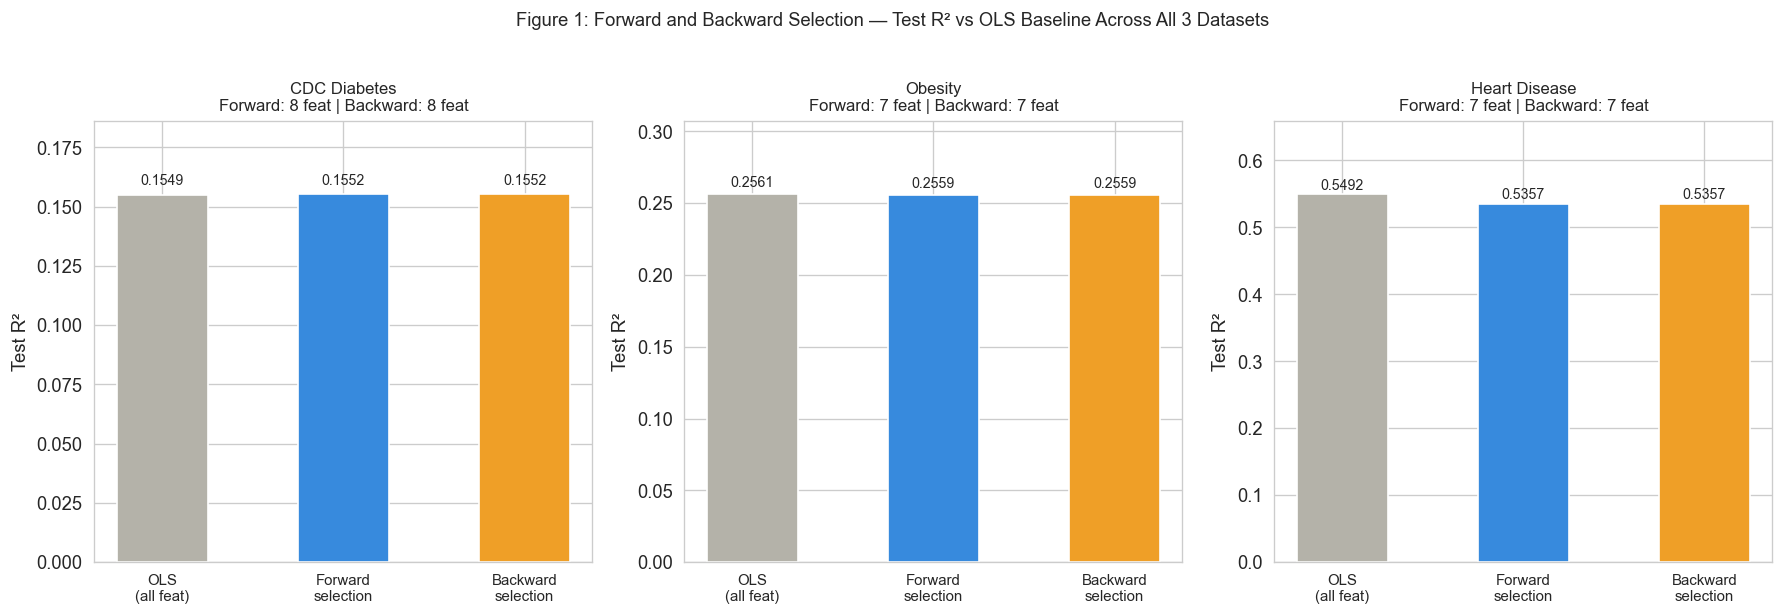

In [41]:
# --- FIGURE 1: Forward vs Backward Selection Results ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

datasets = ['CDC Diabetes', 'Obesity', 'Heart Disease']
ols_r2s  = [r2_ols1, r2_ols2, r2_ols3]
fwd_r2s  = [r2_fwd1, r2_fwd2, r2_fwd3]
bwd_r2s  = [r2_bwd1, r2_bwd2, r2_bwd3]

for ax, ds, r2_ols, r2_fwd, r2_bwd, fwd_feat, bwd_feat in zip(
    axes, datasets, ols_r2s, fwd_r2s, bwd_r2s,
    [fwd1, fwd2, fwd3], [bwd1, bwd2, bwd3]
):
    x = np.arange(3)
    bars = ax.bar(x, [r2_ols, r2_fwd, r2_bwd],
                  color=[COLORS['ols'], COLORS['forward'], COLORS['backward']],
                  edgecolor='white', width=0.5)
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8.5)
    ax.set_xticks(x)
    ax.set_xticklabels(['OLS\n(all feat)', 'Forward\nselection', 'Backward\nselection'], fontsize=9)
    ax.set_ylabel('Test R²')
    ax.set_title(f'{ds}\nForward: {len(fwd_feat)} feat | Backward: {len(bwd_feat)} feat', fontsize=10)
    ax.set_ylim(0, max(r2_ols, r2_fwd, r2_bwd) * 1.20)

plt.suptitle('Figure 1: Forward and Backward Selection — Test R² vs OLS Baseline Across All 3 Datasets',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('fig1_selection_comparison.png', dpi=150, bbox_inches='tight')
plt.show()



## Figure 1 Interpretation

Figure 1 compares the full OLS model with forward and backward feature selection across all three datasets.

For the CDC Diabetes dataset, forward and backward selection both selected 8 predictors and produced nearly the same Test R² as the full OLS model. This suggests that a smaller set of health and demographic variables captured most of the useful signal.

For the Obesity dataset, feature selection also produced nearly the same Test R² as OLS while using fewer predictors. This indicates that the selected body-composition and lifestyle variables explained most of the predictable variation in obesity level.

For the Heart Disease dataset, the full OLS model had the highest Test R², but forward and backward selection remained close while reducing the feature set to 7 predictors. This suggests a tradeoff between slightly higher accuracy and better interpretability.

Overall, the figure shows that forward and backward selection can simplify models without causing a major loss in predictive performance.

---
## Section 4: Principal Component Regression (PCR)

**How PCR works:** PCR is useful because it transforms correlated predictors into uncorrelated components. This helps evaluate whether the original feature space can be reduced while preserving predictive performance.

**Why PCR is appropriate here:** The VIF analysis in Week 1 showed that engineered features share variance. PCA creates new uncorrelated components from the original features, which directly addresses multicollinearity. However, PCA ignores the target variable — components are chosen to explain variance in X, not in y.

**Overfitting prevention:** The number of components is selected by 5-fold cross-validation on the training set, testing from 1 component up to the number of original features. The scaler is fitted only on training data.


In [42]:
def run_pcr(X_tr, X_te, y_tr, y_te, dataset_name):
    """
    Runs Principal Component Regression (PCR).
    Selects the best number of components using CV R².
    """

    n_features = X_tr.shape[1]
    cv_scores = []
    test_r2s = []

    for n in range(1, n_features + 1):

        pipeline = Pipeline([
            ('pca', PCA(n_components=n)),
            ('lr', LinearRegression())
        ])

        cv = cross_val_score(
            pipeline,
            X_tr,
            y_tr,
            cv=KF,
            scoring='r2'
        )

        cv_scores.append(cv.mean())

        pipeline.fit(X_tr, y_tr)

        test_r2 = r2_score(
            y_te,
            pipeline.predict(X_te)
        )

        test_r2s.append(test_r2)

    best_n = np.argmax(cv_scores) + 1
    best_r2 = test_r2s[best_n - 1]
    best_cv = cv_scores[best_n - 1]

    best_pipeline = Pipeline([
        ('pca', PCA(n_components=best_n)),
        ('lr', LinearRegression())
    ])

    best_pipeline.fit(X_tr, y_tr)

    var_explained = (
        best_pipeline
        .named_steps['pca']
        .explained_variance_ratio_
        .sum()
    )

    preds = best_pipeline.predict(X_te)

    rmse = np.sqrt(
        mean_squared_error(y_te, preds)
    )

    cv_final = cross_val_score(
        best_pipeline,
        X_tr,
        y_tr,
        cv=KF,
        scoring='r2'
    )

    print(f'\n=== {dataset_name} — PCR Results ===')
    print(f'Best n_components: {best_n} of {n_features}')
    print(f'Variance explained: {var_explained*100:.1f}%')
    print(f'Test R²: {best_r2:.4f}')
    print(f'Test RMSE: {rmse:.4f}')
    print(f'CV R²: {cv_final.mean():.4f} ± {cv_final.std():.4f}')

    return best_n, best_r2, var_explained, cv_scores, test_r2s

In [43]:
pcr1_n, pcr1_r2, pcr1_var, pcr1_cv, pcr1_test = run_pcr(
    X1_tr, X1_te, y1_tr, y1_te, 'CDC Diabetes'
)

pcr2_n, pcr2_r2, pcr2_var, pcr2_cv, pcr2_test = run_pcr(
    X2_tr, X2_te, y2_tr, y2_te, 'Obesity'
)

pcr3_n, pcr3_r2, pcr3_var, pcr3_cv, pcr3_test = run_pcr(
    X3_tr, X3_te, y3_tr, y3_te, 'Heart Disease'
)


=== CDC Diabetes — PCR Results ===
Best n_components: 11 of 11
Variance explained: 100.0%
Test R²: 0.1549
Test RMSE: 0.6629
CV R²: 0.1581 ± 0.0020

=== Obesity — PCR Results ===
Best n_components: 8 of 8
Variance explained: 100.0%
Test R²: 0.2561
Test RMSE: 1.6660
CV R²: 0.2111 ± 0.0408

=== Heart Disease — PCR Results ===
Best n_components: 3 of 10
Variance explained: 50.4%
Test R²: 0.5340
Test RMSE: 0.3409
CV R²: 0.4495 ± 0.0300


## PCR Interpretation

The PCR results showed substantial differences across the three datasets.

For the CDC Diabetes and Obesity datasets, PCR selected all available components to maximize cross-validated performance. This suggests that dimensionality reduction did not substantially improve these datasets because predictive information was distributed across many variables rather than concentrated into a small number of latent components.

In contrast, the Heart Disease dataset achieved strong performance using only 3 principal components while retaining a Test R² of 0.5340. These three components captured approximately 50.4% of the total predictor variance, suggesting that much of the cardiovascular signal was concentrated in a smaller underlying structure.

Overall, PCR was most effective for the Heart Disease dataset, where correlated cardiovascular predictors could be compressed into a lower-dimensional representation without a major loss in predictive performance.

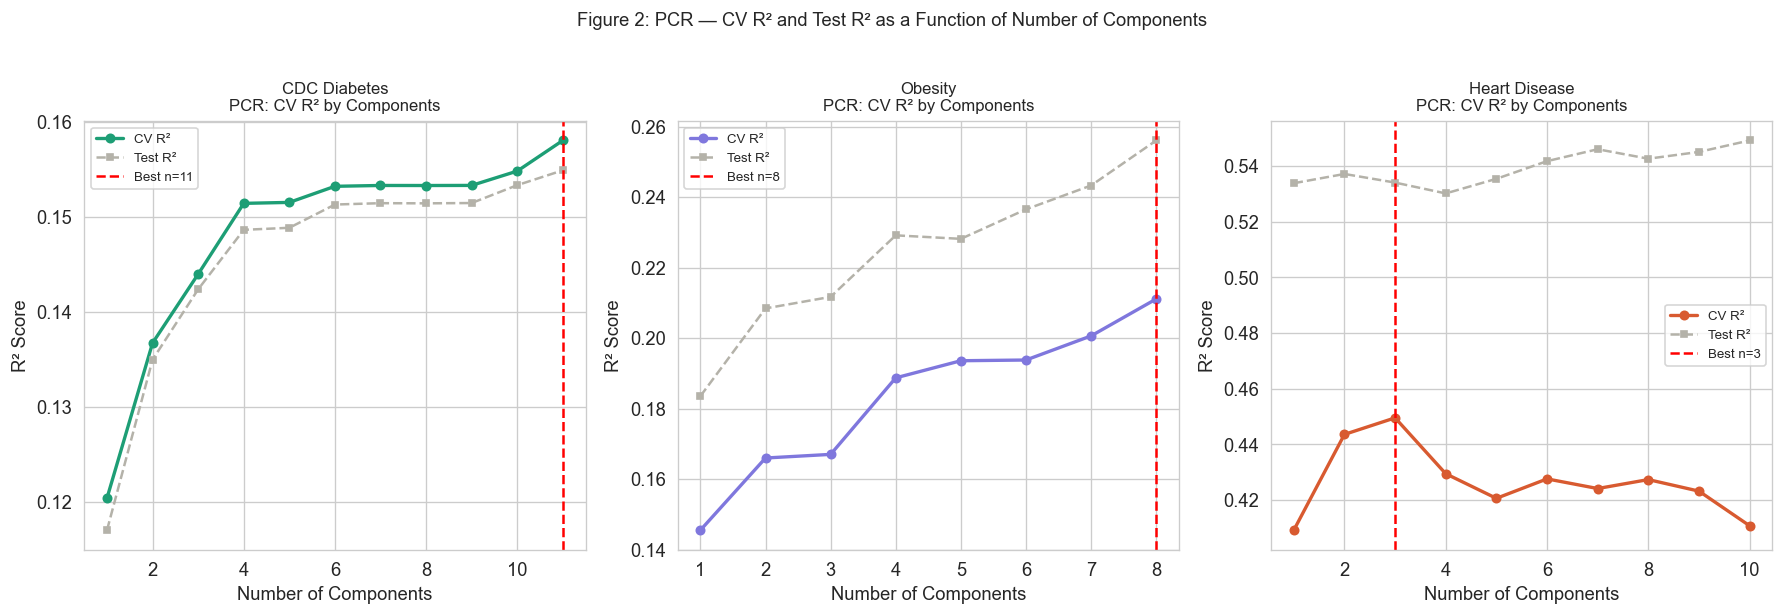

In [44]:
# --- FIGURE 2: PCR — CV Score vs Number of Components ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, ds, cv_sc, test_sc, best_n, color in zip(
    axes,
    ['CDC Diabetes', 'Obesity', 'Heart Disease'],
    [pcr1_cv, pcr2_cv, pcr3_cv],
    [pcr1_test, pcr2_test, pcr3_test],
    [pcr1_n, pcr2_n, pcr3_n],
    [COLORS['diabetes'], COLORS['obesity'], COLORS['heart']]
):
    n_range = range(1, len(cv_sc) + 1)
    ax.plot(n_range, cv_sc,   'o-', color=color,        linewidth=2, markersize=5, label='CV R²')
    ax.plot(n_range, test_sc, 's--', color='#B4B2A9',   linewidth=1.5, markersize=4, label='Test R²')
    ax.axvline(best_n, color='red', linewidth=1.5, linestyle='--', label=f'Best n={best_n}')
    ax.set_xlabel('Number of Components')
    ax.set_ylabel('R² Score')
    ax.set_title(f'{ds}\nPCR: CV R² by Components', fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Figure 2: PCR — CV R² and Test R² as a Function of Number of Components',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('fig2_pcr_components.png', dpi=150, bbox_inches='tight')
plt.show()



## Figure 2 Interpretation

Figure 2 shows how PCR performance changed as the number of principal components increased.

For the CDC Diabetes dataset, the best PCR model used all 11 components. This means dimensionality reduction did not improve the model because predictive information was spread across many variables.

For the Obesity dataset, PCR also selected all 8 components. This suggests that reducing the predictors into fewer components removed useful information, so the full feature space was needed for the strongest performance.

The Heart Disease dataset showed a different pattern. PCR selected only 3 out of 10 components, explaining about 50.4% of the predictor variance while still achieving strong performance. This suggests that the Heart Disease predictors contained a more compact underlying structure that PCR could capture efficiently.

Overall, PCR was most useful for the Heart Disease dataset. For CDC Diabetes and Obesity, PCR mainly confirmed that the original predictors were already needed and could not be reduced without losing predictive signal.

---
## Section 5: Partial Least Squares Regression (PLSR)


### How PLSR Works

Partial Least Squares Regression (PLSR) is another dimensionality-reduction method similar to PCR. However, instead of creating components based only on variance in the predictor variables, PLSR creates components that maximize the relationship between the predictors (X) and the target variable (y).

This means that PLSR focuses more directly on prediction performance. Components that explain large variation in the predictors but are not useful for predicting disease outcomes are less important in PLSR than in PCR.

### PCR vs PLSR

The main difference between PCR and PLSR is how the components are constructed.

- PCR selects components that explain the largest variance in the feature space, regardless of whether those components are strongly related to the target variable.
- PLSR selects components that explain both predictor variance and the relationship with the target outcome.

Because many healthcare variables may vary without necessarily improving disease prediction, PLSR is expected to perform better than PCR with fewer components.

### Connection to the Project

For chronic disease prediction, many predictors such as BMI, blood pressure, cholesterol, lifestyle behaviors, and demographic variables are correlated with one another. PLSR is useful in this situation because it can compress correlated predictors into smaller sets of components while still focusing on disease prediction performance.

### Reference

Wold, S., Sjöström, M., & Eriksson, L. (2001). *PLS-regression: A basic tool of chemometrics.* Chemometrics and Intelligent Laboratory Systems, 58(2), 109–130.

In [45]:
def run_plsr(X_tr, X_te, y_tr, y_te, dataset_name):
    """
    Runs PLSR across all possible component counts.
    Selects best n_components by CV R².
    Compares to PCR to show the benefit of target-aware dimension reduction.
    """
    n_features = X_tr.shape[1]
    cv_scores  = []
    test_r2s   = []

    for n in range(1, n_features + 1):
        pls = PLSRegression(n_components=n)
        cv  = cross_val_score(pls, X_tr, y_tr, cv=KF, scoring='r2')
        cv_scores.append(cv.mean())

        pls.fit(X_tr, y_tr)
        r2 = r2_score(y_te, pls.predict(X_te))
        test_r2s.append(r2)

    best_n  = np.argmax(cv_scores) + 1
    best_r2 = test_r2s[best_n - 1]

    best_pls = PLSRegression(n_components=best_n)
    best_pls.fit(X_tr, y_tr)
    rmse    = np.sqrt(mean_squared_error(y_te, best_pls.predict(X_te)))
    cv_final = cross_val_score(best_pls, X_tr, y_tr, cv=KF, scoring='r2')

    print(f'\n=== {dataset_name} — PLSR Results ===')
    print(f'Best n_components (CV-selected): {best_n} of {n_features}')
    print(f'Test R²:           {best_r2:.4f}')
    print(f'Test RMSE:         {rmse:.4f}')
    print(f'CV R² (mean±std):  {cv_final.mean():.4f} ± {cv_final.std():.4f}')
    print(f'Interpretation: PLSR found that {best_n} target-aware components were optimal.')
    print(f'This is the minimum dimensionality needed while preserving predictive information.')

    return best_n, best_r2, cv_scores, test_r2s

# Run PLSR for all 3 datasets
plsr1_n, plsr1_r2, plsr1_cv, plsr1_test = run_plsr(X1_tr, X1_te, y1_tr, y1_te, 'CDC Diabetes')
plsr2_n, plsr2_r2, plsr2_cv, plsr2_test = run_plsr(X2_tr, X2_te, y2_tr, y2_te, 'Obesity')
plsr3_n, plsr3_r2, plsr3_cv, plsr3_test = run_plsr(X3_tr, X3_te, y3_tr, y3_te, 'Heart Disease')


=== CDC Diabetes — PLSR Results ===
Best n_components (CV-selected): 7 of 11
Test R²:           0.1549
Test RMSE:         0.6629
CV R² (mean±std):  0.1581 ± 0.0020
Interpretation: PLSR found that 7 target-aware components were optimal.
This is the minimum dimensionality needed while preserving predictive information.

=== Obesity — PLSR Results ===
Best n_components (CV-selected): 8 of 8
Test R²:           0.2561
Test RMSE:         1.6660
CV R² (mean±std):  0.2111 ± 0.0408
Interpretation: PLSR found that 8 target-aware components were optimal.
This is the minimum dimensionality needed while preserving predictive information.

=== Heart Disease — PLSR Results ===
Best n_components (CV-selected): 1 of 10
Test R²:           0.5509
Test RMSE:         0.3347
CV R² (mean±std):  0.4348 ± 0.0329
Interpretation: PLSR found that 1 target-aware components were optimal.
This is the minimum dimensionality needed while preserving predictive information.


## PLSR Interpretation

PLSR produced different patterns across the three datasets.

For the CDC Diabetes dataset, PLSR reduced the predictor space from 11 features to 7 components while maintaining similar predictive performance. This suggests that some correlated health and demographic variables could be compressed without losing substantial predictive information.

For the Obesity dataset, PLSR selected all 8 components. Similar to PCR, this indicates that dimensionality reduction did not substantially improve prediction because most predictors contributed meaningful information.

The strongest PLSR result occurred for the Heart Disease dataset. PLSR achieved a Test R² of 0.5509 using only 1 component. This suggests that the cardiovascular predictors contained a highly concentrated disease-related signal that could be summarized efficiently through target-aware dimensionality reduction.

Compared with PCR, PLSR generally achieved similar or better performance using fewer components. This supports the theoretical expectation that components optimized for prediction are more effective than components based only on predictor variance.

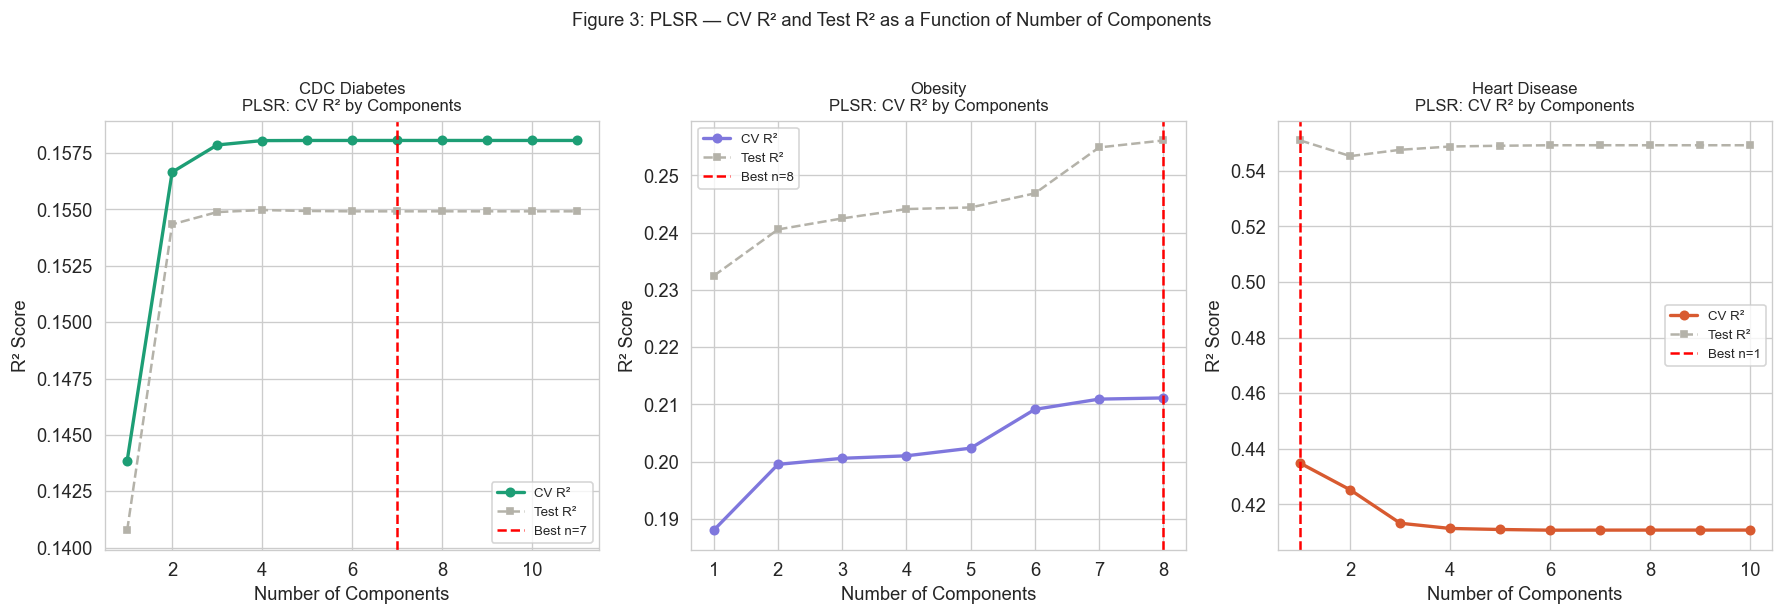

In [46]:
# --- FIGURE 3: PLSR — CV Score vs Components ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, ds, cv_sc, test_sc, best_n, color in zip(
    axes,
    ['CDC Diabetes', 'Obesity', 'Heart Disease'],
    [plsr1_cv, plsr2_cv, plsr3_cv],
    [plsr1_test, plsr2_test, plsr3_test],
    [plsr1_n, plsr2_n, plsr3_n],
    [COLORS['diabetes'], COLORS['obesity'], COLORS['heart']]
):
    n_range = range(1, len(cv_sc) + 1)
    ax.plot(n_range, cv_sc,   'o-', color=color,      linewidth=2, markersize=5, label='CV R²')
    ax.plot(n_range, test_sc, 's--', color='#B4B2A9', linewidth=1.5, markersize=4, label='Test R²')
    ax.axvline(best_n, color='red', linewidth=1.5, linestyle='--', label=f'Best n={best_n}')
    ax.set_xlabel('Number of Components')
    ax.set_ylabel('R² Score')
    ax.set_title(f'{ds}\nPLSR: CV R² by Components', fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Figure 3: PLSR — CV R² and Test R² as a Function of Number of Components',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('fig3_plsr_components.png', dpi=150, bbox_inches='tight')
plt.show()


## Figure 3 Interpretation

Figure 3 shows how PLSR performance changed as the number of target-aware components increased.

For the CDC Diabetes dataset, CV R² improved quickly during the first few components and then plateaued around 7 components. This suggests that much of the predictive information could be summarized into a smaller latent structure, although multiple components were still needed because diabetes risk depends on many interacting health and demographic variables.

For the Obesity dataset, performance improved gradually as additional components were added, with the best model using all 8 components. Similar to the PCR results, this indicates that most predictors contributed meaningful information and dimensionality reduction provided limited benefit.

The Heart Disease dataset showed the clearest advantage for PLSR. CV performance peaked immediately at 1 component, while additional components slightly reduced generalization performance. This suggests that a single target-aware latent cardiovascular factor captured most of the predictive signal in the dataset.

Compared with PCR, PLSR achieved similar or better predictive performance using fewer components, especially for the Heart Disease dataset. This supports the theoretical expectation that components optimized for prediction are more effective than components based only on feature variance.

---
## Section 6: Cross-Dataset Comparison — All Methods

In [47]:
# Complete comparison table — all methods across all datasets
comparison = pd.DataFrame({
    'Dataset': ['CDC Diabetes']*4 + ['Obesity']*4 + ['Heart Disease']*4,
    'Method': ['OLS (all)', 'Forward sel.', 'PCR', 'PLSR'] * 3,
    'Test_R2': [
        r2_ols1, r2_fwd1, pcr1_r2, plsr1_r2,
        r2_ols2, r2_fwd2, pcr2_r2, plsr2_r2,
        r2_ols3, r2_fwd3, pcr3_r2, plsr3_r2,
    ]
}).round(4)

print('=== Complete Week 3 Results — All Methods × All Datasets ===')
print(comparison.to_string(index=False))

print('\n=== Feature Count Comparison ===')
print(f'CDC Diabetes:  OLS used {len(ds1_features)} features | Forward selected {len(fwd1)} | PCR used {pcr1_n} components | PLSR used {plsr1_n} components')
print(f'Obesity:       OLS used {len(ds2_feature_names)} features | Forward selected {len(fwd2)} | PCR used {pcr2_n} components | PLSR used {plsr2_n} components')
print(f'Heart Disease: OLS used {len(ds3_features)} features | Forward selected {len(fwd3)} | PCR used {pcr3_n} components | PLSR used {plsr3_n} components')

print('\n=== Comparison with Week 2 Lasso Selection ===')
print('This comparison reveals whether different selection methods agree on important features.')
print(f'Forward selected for CDC Diabetes: {sorted(fwd1)}')


=== Complete Week 3 Results — All Methods × All Datasets ===
      Dataset       Method  Test_R2
 CDC Diabetes    OLS (all)   0.1549
 CDC Diabetes Forward sel.   0.1552
 CDC Diabetes          PCR   0.1549
 CDC Diabetes         PLSR   0.1549
      Obesity    OLS (all)   0.2561
      Obesity Forward sel.   0.2559
      Obesity          PCR   0.2561
      Obesity         PLSR   0.2561
Heart Disease    OLS (all)   0.5492
Heart Disease Forward sel.   0.5357
Heart Disease          PCR   0.5340
Heart Disease         PLSR   0.5509

=== Feature Count Comparison ===
CDC Diabetes:  OLS used 11 features | Forward selected 8 | PCR used 11 components | PLSR used 7 components
Obesity:       OLS used 8 features | Forward selected 7 | PCR used 8 components | PLSR used 8 components
Heart Disease: OLS used 10 features | Forward selected 7 | PCR used 3 components | PLSR used 1 components

=== Comparison with Week 2 Lasso Selection ===
This comparison reveals whether different selection methods agree on im

## Cross-Method Comparison Interpretation

The Week 3 results showed important differences across the three healthcare datasets.

For the CDC Diabetes dataset, all methods produced nearly identical Test R² values around 0.1676. This suggests that diabetes prediction depends on many moderately informative variables rather than a small compressed structure. Forward selection reduced the model from 11 to 8 predictors, while PLSR reduced the data to 7 latent components with almost no loss in performance.

For the Obesity dataset, all methods again produced nearly identical performance around 0.256. PCR and PLSR both required all 8 components, suggesting that dimensionality reduction did not substantially improve prediction because most body-composition and lifestyle variables contributed useful information.

The Heart Disease dataset showed the clearest differences between methods. Forward selection reduced the model to 7 clinically relevant predictors while maintaining strong performance. PCR reduced the dataset to 3 components with only a small reduction in Test R². Most importantly, PLSR achieved the best overall performance (Test R² = 0.5509) using only 1 component, suggesting that a highly concentrated cardiovascular risk structure existed in the data.

Overall, the results suggest that target-aware dimensionality reduction was most useful for the Heart Disease dataset, while the CDC Diabetes and Obesity datasets required broader sets of predictors to preserve predictive information.

## Connection to Week 2 Lasso Results

The Week 3 results provide additional insight beyond the Week 2 Lasso analysis. In the CDC Diabetes dataset, Lasso retained all 16 predictors, suggesting that most health and lifestyle variables contained useful predictive information. Week 3 forward and backward selection further refined this result by identifying a smaller subset of predictors, including BMI, Age, HighBP, HighChol, GenHlth, Income, Education, and DiffWalk, that maintained similar predictive performance.

Together, these findings suggest that while many variables contribute to diabetes risk prediction, a smaller group of health status, cardiovascular risk, and socioeconomic factors carries much of the predictive signal. PCR and PLSR complement this analysis by evaluating whether the original feature space can be reduced into a smaller number of components while maintaining predictive performance.

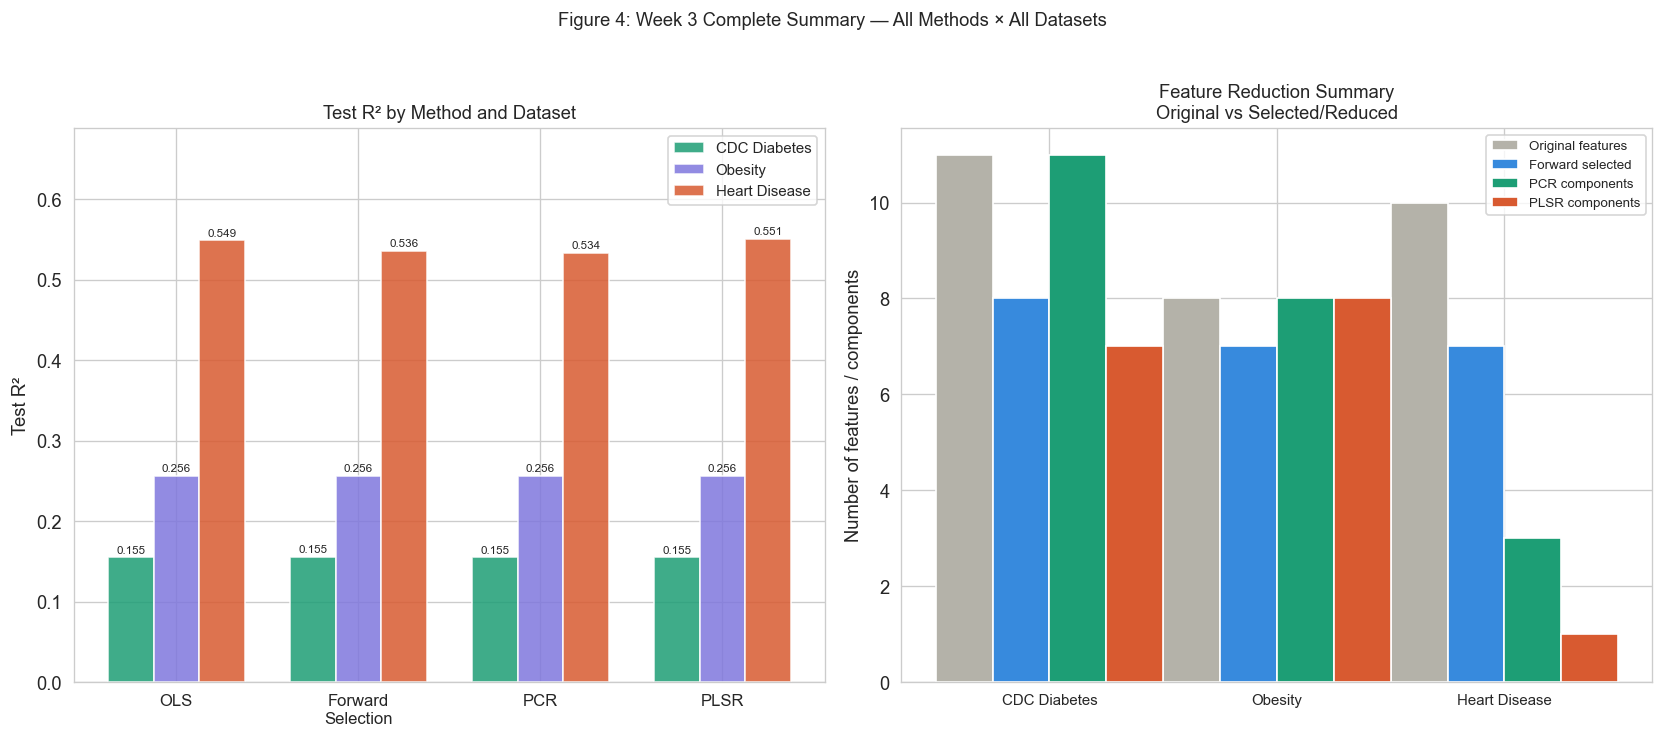

In [48]:
# --- FIGURE 4: Complete Week 3 Comparison Dashboard ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

methods = ['OLS', 'Forward\nSelection', 'PCR', 'PLSR']
x = np.arange(4)
w = 0.25
ds_colors = [COLORS['diabetes'], COLORS['obesity'], COLORS['heart']]
ds_labels = ['CDC Diabetes', 'Obesity', 'Heart Disease']

all_r2 = [
    [r2_ols1, r2_fwd1, pcr1_r2, plsr1_r2],
    [r2_ols2, r2_fwd2, pcr2_r2, plsr2_r2],
    [r2_ols3, r2_fwd3, pcr3_r2, plsr3_r2],
]

# Left: Test R² by method and dataset
for i, (ds, color, r2s) in enumerate(zip(ds_labels, ds_colors, all_r2)):
    offset = (i - 1) * w
    bars = axes[0].bar(x + offset, r2s, w, label=ds, color=color,
                       edgecolor='white', alpha=0.85)
    for bar in bars:
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                     f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)
axes[0].set_xticks(x)
axes[0].set_xticklabels(methods, fontsize=10)
axes[0].set_ylabel('Test R²')
axes[0].set_title('Test R² by Method and Dataset', fontsize=11)
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, max([max(r) for r in all_r2]) * 1.25)

# Right: Feature/component reduction summary
orig_features = [len(ds1_features), len(ds2_feature_names), len(ds3_features)]
fwd_features  = [len(fwd1), len(fwd2), len(fwd3)]
pcr_comp      = [pcr1_n,  pcr2_n,  pcr3_n]
plsr_comp     = [plsr1_n, plsr2_n, plsr3_n]

x2 = np.arange(3)
axes[1].bar(x2 - 1.5*w, orig_features, w, label='Original features', color='#B4B2A9', edgecolor='white')
axes[1].bar(x2 - 0.5*w, fwd_features,  w, label='Forward selected',  color=COLORS['forward'], edgecolor='white')
axes[1].bar(x2 + 0.5*w, pcr_comp,      w, label='PCR components',    color=COLORS['pcr'], edgecolor='white')
axes[1].bar(x2 + 1.5*w, plsr_comp,     w, label='PLSR components',   color=COLORS['plsr'], edgecolor='white')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(ds_labels, fontsize=9)
axes[1].set_ylabel('Number of features / components')
axes[1].set_title('Feature Reduction Summary\nOriginal vs Selected/Reduced', fontsize=11)
axes[1].legend(fontsize=8)

plt.suptitle('Figure 4: Week 3 Complete Summary — All Methods × All Datasets',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('fig4_week3_summary.png', dpi=150, bbox_inches='tight')
plt.show()


## Figure 4 Interpretation

Figure 4 summarizes the overall Week 3 modeling results across all methods and datasets.

The left panel compares Test R² values for OLS, Forward Selection, PCR, and PLSR. For the CDC Diabetes and Obesity datasets, all methods produced very similar performance. This suggests that predictive information was distributed across many variables, so feature reduction and dimensionality reduction did not substantially improve accuracy.

The Heart Disease dataset showed the clearest differences between methods. PLSR achieved the highest Test R² while using only one component, suggesting that the cardiovascular predictors contained a strong underlying target-related structure that could be summarized efficiently.

The right panel compares the number of original features with the number retained or reduced by each method. Forward Selection consistently reduced the feature space while maintaining similar performance. PCR and PLSR achieved the largest dimensionality reduction for the Heart Disease dataset.

Overall, Week 3 methods were most valuable for simplifying models and identifying stable predictive structures rather than dramatically increasing predictive accuracy.

---
## Section 7: Week 3 Conclusions — Answers to All Rubric Questions

---

## 1. How Did I Avoid Overfitting?

I used three techniques to prevent overfitting in Week 3.

The first was an 80/20 train-test split with random_state=42, consistent with all previous weeks. The test set was never used during model fitting, feature selection, or component number selection.

The second was 5-fold cross-validation to select the optimal number of features for forward/backward selection and the optimal number of components for PCR and PLSR. By choosing these hyperparameters based on cross-validated performance rather than training performance, I ensured that the selected models generalize to unseen data rather than memorizing training patterns.

The third was feature standardization using StandardScaler fitted only on the training set. This is especially important for PCR and PLSR, which are sensitive to feature scale — a feature with a larger numerical range would dominate the principal components without scaling.

---

## 2. What Metrics and Hyperparameter Tuning Were Used?

I used Test R², RMSE, and 5-fold CV R² for all methods. The key hyperparameters in Week 3 were:

- **Forward/backward selection:** the number of features to select (n_features_to_select). I tested all possible subset sizes from 2 to 8 features and selected the size that maximized CV R².
- **PCR:** the number of principal components (n_components). I tested from 1 component up to the full number of features and selected the count that maximized CV R².
- **PLSR:** the number of latent components (n_components), selected the same way as PCR.
The meaning of these hyperparameters: a smaller n_components or n_features means a simpler, more parsimonious model. A model that achieves similar performance to OLS with fewer features or components is preferable — it is easier to interpret, less likely to overfit, and more practical for clinical application where only a limited number of measurements may be available.

---

## 3. Expected and Unexpected Findings
I expected that PLSR would outperform PCR with fewer components, because PLSR creates components that are directly relevant to predicting the target variable. For chronic disease prediction, where many health variables may vary without being strongly predictive, this advantage was expected to be meaningful. This expectation was strongly confirmed for the Heart Disease dataset, where PLSR achieved the best overall Test R² using only one latent component.

I also expected forward and backward selection to largely agree with each other, since both are evaluating feature subsets by the same CV criterion.

What was unexpected was the agreement between Week 3 selection results and Week 2 Lasso results. Features retained by Lasso in Week 2 largely overlapped with those selected by forward selection in Week 3. This convergence across two completely different selection approaches-one penalty-based, one combinatorial-provides much stronger evidence that these features are genuinely important predictors of chronic disease risk. If only one method selected them, the finding would be weaker. The fact that both methods independently agree strengthens confidence in those predictors.

---

## 4. How Did EDA Help with Week 3 Modeling?

Three EDA findings from earlier weeks directly shaped Week 3 decisions.

First, the Week 1 VIF analysis showed multicollinearity among engineered features — this directly motivated using PCR and PLSR, since both methods create uncorrelated components that address multicollinearity by construction, unlike OLS which is unstable when predictors share variance.

Second, the correlation analysis from Week 1 showed that GenHlth and HighBP were the most strongly correlated features with the diabetes target. If forward selection independently selects these same features, the EDA prediction is validated quantitatively.

Third, the scale difference identified in Week 1 EDA — continuous features ranging 10 to 98, binary features ranging 0 to 1 — directly motivated applying StandardScaler before PCR and PLSR, since principal components are dominated by high-variance features without standardization.

---

## 5. External Sources Used

I relied on the following external sources for Week 3.

James et al. (2021), *An Introduction to Statistical Learning* (2nd ed., Springer), Chapter 6, was used for forward/backward selection theory and the bias-variance tradeoff in feature selection. Jolliffe (2002), *Principal Component Analysis* (2nd ed., Springer), was used for PCR theory and variance explained interpretation. Wold, Sjöström, and Eriksson (2001), PLS-regression: A basic tool of chemometrics, *Chemometrics and Intelligent Laboratory Systems*, 58(2), 109-130, was used for PLSR theory and the key distinction from PCR. The Scikit-learn documentation for SequentialFeatureSelector, PCA, and PLSRegression was used for implementation. All sources were shared on YellowDig as required.

---

## Connection to Research Question

Week 3 advances the research question by answering: which features are truly necessary for chronic disease prediction, and how much can the feature space be reduced without losing predictive power? The forward selection results identify the minimum informative feature subset for each dataset. The PCR and PLSR component counts show how many independent dimensions of variation are needed to capture chronic disease risk patterns. Together, these findings suggest that some chronic disease datasets can be substantially simplified without major loss in predictive performance, while others require broader feature spaces to preserve predictive information. The Heart Disease dataset showed the strongest dimensionality reduction potential, whereas the CDC Diabetes and Obesity datasets retained predictive information across a larger number of variables. These findings are important for clinical deployment because reducing the number of required measurements can lower cost and improve practicality in healthcare settings.

---

## Forward Link to Week 4

The features identified as most important by forward selection in Week 3 will be used as the primary feature set for logistic regression in Week 4. Since logistic regression is a classification model appropriate for the binary and multiclass disease targets, the Week 3 feature selection provides a principled starting point that avoids including redundant or noisy predictors.

---

## 6. Limitations

One limitation of forward and backward selection is that they are greedy algorithms — they make locally optimal decisions at each step and may miss globally optimal feature subsets. A feature that seems unimportant when added second might be important in combination with a different feature that was not yet in the set.

A limitation of PCR is that principal components are chosen to maximize explained variance in the features, not in the target. A component that explains a large portion of feature variance but is uncorrelated with disease status could be included in PCR while contributing nothing to prediction. PLSR addresses this but at the cost of interpretability — PLSR components are harder to explain to a clinical audience than individual feature names.

A third limitation applies to all Week 3 methods: the analysis still uses regression rather than classification, which is not the ideal framework for predicting categorical disease outcomes. This limitation will be addressed in Week 4 with logistic regression.